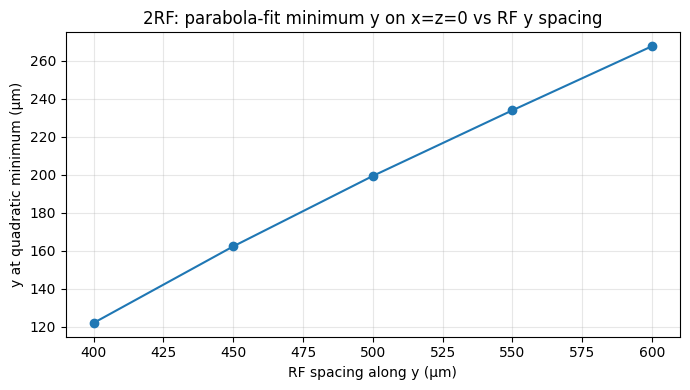

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in (here, here.parent):
        if (p / "FieldConfiguration" / "configs" / "2RF.json").is_file():
            return p
    raise FileNotFoundError(
        "Could not find repo root (FieldConfiguration/configs/2RF.json). "
        "Run the notebook from the repository root or from tools/."
    )


_ROOT = _repo_root()
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from FieldConfiguration.constants import init_from_config, m as ION_MASS
from FieldConfiguration.loader import field_settings_from_config
from FieldParser.calc_field import calc_field, calc_potential
from FieldParser.csv_reader import read as read_csv
from FieldParser.potential_fit import (
    fit_potential_1d,
    get_center_and_k2,
    k2_to_trap_freq_MHz,
)
from field_visualize.core import compute_potentials

config_path = _ROOT / "FieldConfiguration/configs/2RF.json"
data_dir = _ROOT / "data/2RF"
y_dists_um = [400, 450, 500, 550, 600]

cfg, _ = init_from_config(config_path)

y_um_at_min_total: list[float] = []
trap_freq_y_quad_mhz: list[float] = []
for d_um in y_dists_um:
    csv_path = data_dir / f"y_dist_{d_um}.csv"
    fs = field_settings_from_config(str(csv_path), config_path, n_voltage=2, cfg=cfg)
    grid_coord, grid_voltage = read_csv(
        csv_path, fs, normalize=True, dl=cfg.dl, dV=cfg.dV
    )
    potential_interps = calc_potential(grid_coord, grid_voltage)
    field_interps = calc_field(grid_coord, grid_voltage)
    _, _, _, v_total = compute_potentials(
        potential_interps,
        field_interps,
        fs.voltage_list,
        cfg,
        grid_coord,
    )
    on_y_axis = np.isclose(grid_coord[:, 0], 0.0) & np.isclose(grid_coord[:, 2], 0.0)
    y_norm_line = grid_coord[on_y_axis, 1]
    v_line = v_total[on_y_axis]
    y_um_line = y_norm_line * cfg.dl / 1e-6
    valid = np.isfinite(v_line) & np.isfinite(y_um_line)
    if np.sum(valid) < 3:
        y_um_at_min_total.append(float("nan"))
        trap_freq_y_quad_mhz.append(float("nan"))
    else:
        try:
            fit_result, _r2 = fit_potential_1d(
                y_um_line[valid], v_line[valid], degree=2
            )
            _center, _a, _b, c_quad = fit_result[:4]
            if c_quad <= 0:
                y_um_at_min_total.append(float("nan"))
                trap_freq_y_quad_mhz.append(float("nan"))
            else:
                y_um_at_min_total.append(float(fit_result[0]))
                _, k2 = get_center_and_k2(fit_result, 2)
                trap_freq_y_quad_mhz.append(k2_to_trap_freq_MHz(k2, ION_MASS))
        except ValueError:
            y_um_at_min_total.append(float("nan"))
            trap_freq_y_quad_mhz.append(float("nan"))

fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.plot(y_dists_um, y_um_at_min_total, marker="o")
ax.set_xlabel("RF spacing along y (μm)")
ax.set_ylabel("y at quadratic minimum (μm)")
ax.set_title("2RF: parabola-fit minimum y on x=z=0 vs RF y spacing")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


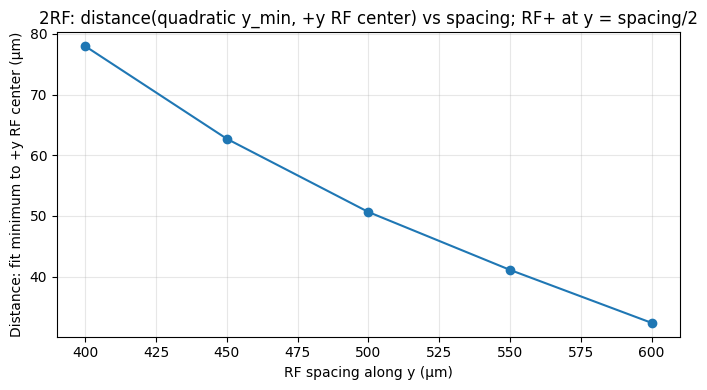

In [4]:
# Run the previous cell first (defines y_dists_um, y_um_at_min_total).
# RF centers at y = ±(RF spacing / 2) μm; spacing is the center-to-center distance y_dists_um.

y_rf_center_positive_um = np.asarray(y_dists_um, dtype=float) / 2.0
y_min_fit_um = np.asarray(y_um_at_min_total, dtype=float)
dist_min_to_rf_pos_um = np.abs(y_rf_center_positive_um - y_min_fit_um)

fig2, ax2 = plt.subplots(figsize=(7.0, 4.0))
ax2.plot(y_dists_um, dist_min_to_rf_pos_um, marker="o")
ax2.set_xlabel("RF spacing along y (μm)")
ax2.set_ylabel("Distance: fit minimum to +y RF center (μm)")
ax2.set_title(
    "2RF: distance(quadratic y_min, +y RF center) vs spacing; RF+ at y = spacing/2"
)
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
plt.show()


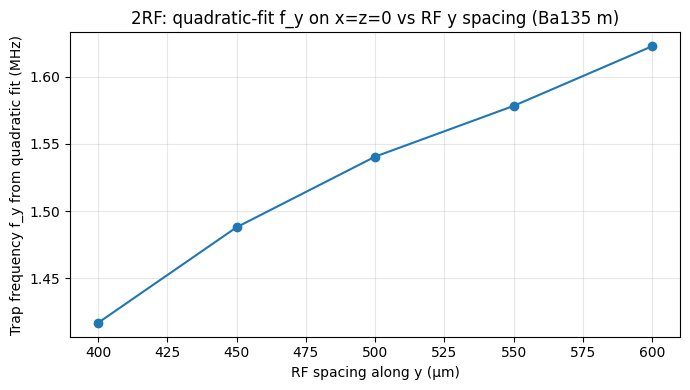

In [ ]:
# Run the first cell first (defines y_dists_um, trap_freq_y_quad_mhz).
# f_y from curvature of the quadratic fit to V_total along y at x=z=0; ion mass from FieldConfiguration.constants (Ba135).

fig3, ax3 = plt.subplots(figsize=(7.0, 4.0))
ax3.plot(y_dists_um, trap_freq_y_quad_mhz, marker="o")
ax3.set_xlabel("RF spacing along y (μm)")
ax3.set_ylabel("Trap frequency f_y from quadratic fit (MHz)")
ax3.set_title("2RF: quadratic-fit f_y on x=z=0 vs RF y spacing (Ba135 m)")
ax3.grid(True, alpha=0.3)
fig3.tight_layout()
plt.show()
